# Exploratory Data Analysis(EDA)
# Разведочный анализ данных

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
df = pd.read_csv('bytebrew-campus-cafe-orders.csv')

df.head()

,order_id,day_of_week,time_slot,student_year,faculty,drink,size,food_item,is_member,payment,raining,price,prep_minutes,calories,tip,rating,study_hours_today,prior_coffee_cups
0,B0301,Tue,late_night,2,Bio,tea,L,croissant,no,card,no,4.49,8,288,0.10,3.0,1.9,1
1,B0266,Tue,morning,2,Bio,cappuccino,L,sandwich,no,campus_card,no,8.16,6,558,0.67,4.0,1.3,3
2,B0064,Fri,late_night,1,Business,hot_chocolate,S,cookie,no,campus_card,yes,4.08,8,382,0.84,4.0,4.8,0
3,B0197,Thu,afternoon,4,Business,americano,S,cookie,yes,card,no,3.19,6,194,0.89,4.0,3.2,0
4,B0261,Fri,morning,2,Design,americano,M,none,yes,card,no,2.48,5,11,0.79,3.0,4.7,1


In [122]:
df.shape

(365, 18)

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           365 non-null    object 
 1   day_of_week        365 non-null    object 
 2   time_slot          365 non-null    object 
 3   student_year       365 non-null    int64  
 4   faculty            365 non-null    object 
 5   drink              365 non-null    object 
 6   size               365 non-null    object 
 7   food_item          365 non-null    object 
 8   is_member          365 non-null    object 
 9   payment            365 non-null    object 
 10  raining            365 non-null    object 
 11  price              365 non-null    float64
 12  prep_minutes       365 non-null    int64  
 13  calories           365 non-null    int64  
 14  tip                336 non-null    float64
 15  rating             356 non-null    float64
 16  study_hours_today  365 non

In [124]:
df.describe()

,student_year,price,prep_minutes,calories,tip,rating,study_hours_today,prior_coffee_cups
count,365.000000,365.000000,365.000000,365.000000,336.000000,356.000000,365.000000,365.000000
mean,2.224658,4.903836,5.980822,294.487671,0.570208,3.904494,3.705479,1.320548
std,1.086351,1.986780,2.434226,193.690356,0.339604,0.751998,1.451135,1.108776
min,1.000000,1.610000,1.000000,0.000000,0.000000,2.000000,0.300000,0.000000
25%,1.000000,3.220000,4.000000,141.000000,0.310000,3.000000,2.700000,0.000000
50%,2.000000,4.480000,6.000000,288.000000,0.580000,4.000000,3.600000,1.000000
75%,3.000000,6.570000,8.000000,436.000000,0.802500,4.000000,4.600000,2.000000
max,4.000000,9.340000,12.000000,747.000000,1.560000,5.000000,8.000000,4.000000


In [125]:
df.columns.tolist()

['order_id',
 'day_of_week',
 'time_slot',
 'student_year',
 'faculty',
 'drink',
 'size',
 'food_item',
 'is_member',
 'payment',
 'raining',
 'price',
 'prep_minutes',
 'calories',
 'tip',
 'rating',
 'study_hours_today',
 'prior_coffee_cups']

In [126]:
df['day_of_week'].value_counts()

,count
day_of_week,
Fri,72
Tue,60
Thu,56
Wed,54
Mon,43
Sat,42
Sun,38


In [127]:
print(df['drink'].value_counts())

drink
cappuccino       60
cold_brew        57
latte            53
smoothie         53
tea              50
americano        47
hot_chocolate    45
Name: count, dtype: int64


In [128]:
df['food_item'].unique()

array(['croissant', 'sandwich', 'cookie', 'none', 'soup', 'salad'],
      dtype=object)

In [129]:
df['food_item'].value_counts()

,count
food_item,
none,145
sandwich,73
croissant,54
salad,39
cookie,38
soup,16


In [130]:
print(df['time_slot'].value_counts())

time_slot
evening       99
afternoon     95
morning       93
late_night    78
Name: count, dtype: int64


# Легкая очистка

In [131]:
print(
    "exact duplicate rows:", df.duplicated().sum()
)

exact duplicate rows: 5


In [132]:
df[df.duplicated()]

,order_id,day_of_week,time_slot,student_year,faculty,drink,size,food_item,is_member,payment,raining,price,prep_minutes,calories,tip,rating,study_hours_today,prior_coffee_cups
83,B0172,Sat,late_night,2,CS,latte,M,soup,no,card,no,6.57,7,353,1.27,4.0,2.1,4
197,B0211,Thu,late_night,1,Arts,smoothie,L,none,yes,card,no,4.37,7,304,0.41,4.0,2.8,1
244,B0267,Fri,morning,4,Bio,americano,M,none,no,card,no,2.66,5,7,NaN,3.0,1.2,1
273,B0119,Sat,evening,1,Law,smoothie,M,sandwich,no,card,yes,8.52,5,691,0.42,4.0,1.2,1
361,B0331,Mon,morning,4,Law,cold_brew,S,croissant,no,card,no,5.14,8,301,0.69,NaN,2.7,2


# очистка

In [133]:
df_clean = df.drop_duplicates().copy(
)
print("shape after drop_duplicates: ", df_clean.shape)

shape after drop_duplicates:  (360, 18)


In [134]:
tip_median = df_clean['tip'].median()
print("tip median:", tip_median
)

df_clean['tip'] = df_clean['tip'].fillna(tip_median)

tip median: 0.58


In [135]:
rating_median = df_clean['rating'].median()
print("RATING MEDIAN:", rating_median)
df_clean['rating'] = df_clean['rating'].fillna(rating_median)

RATING MEDIAN: 4.0


In [136]:
print(df_clean.isna().sum())

order_id             0
day_of_week          0
time_slot            0
student_year         0
faculty              0
drink                0
size                 0
food_item            0
is_member            0
payment              0
raining              0
price                0
prep_minutes         0
calories             0
tip                  0
rating               0
study_hours_today    0
prior_coffee_cups    0
dtype: int64


## 5. Анализы: фильтры и groupby

Несколько коротких вопросов к данным — по одной идее на ячейку.

### 5.1. Средний чек у членов программы лояльности и остальных


In [137]:
# df['is_member'].value_counts()
# df_by_is_member = df.groupby('is_member')

# df_by_is_member.describe()['price']

mean_price_yes = df_clean[df_clean['is_member']=='yes']
print("mean price of members: ", mean_price_yes['price'].mean())

mean_price_no = df_clean[df_clean['is_member']=='no']
print("mean price of not members: ", mean_price_no['price'].mean())

mean price of members:  4.477950819672131
mean price of not members:  5.11063025210084


### 5.2. Какие напитки берут вечером и ночью?


In [138]:
drinks_ev_ni = df_clean[(df_clean['time_slot'] == 'evening') | (df_clean['time_slot'] =='night')]
print("Evening and night drinks: ", drinks_ev_ni['drink'].unique())

Evening and night drinks:  ['cappuccino' 'americano' 'hot_chocolate' 'latte' 'tea' 'cold_brew'
 'smoothie']


### 5.3. Среднее время приготовления по типу еды


In [139]:

df_clean.groupby('food_item')['prep_minutes'].mean()

,prep_minutes
food_item,
cookie,6.947368
croissant,7.566038
none,4.097902
salad,7.512821
sandwich,6.902778
soup,7.333333


### 5.4. Дождь и горячий шоколад — совпадение?


In [140]:

rain_choc = df_clean[(df_clean['drink']=='hot_chocolate') & (df_clean['raining']=='yes')].shape
print("Rain and chocolate: ", rain_choc[0])

Rain and chocolate:  10


### 5.5. Курс студента и средний рейтинг / чаевые


In [141]:
df_clean.groupby('student_year')['tip'].mean()
df_clean.groupby('student_year')['rating'].mean()

,rating
student_year,
1,3.877049
2,3.903226
3,3.988636
4,3.859649


### 5.6. Факультет и калории (кто «слаще» заказывает?)


In [142]:
df_clean.groupby('faculty')['calories'].mean()

,calories
faculty,
Arts,305.483333
Bio,274.169492
Business,301.941176
CS,289.365079
Design,281.463768
Law,315.120690


## 6. Графики

Подписываем оси и заголовки. Без лишнего декора. Каждую диаграмму следет построить через plt и seaborn


In [143]:
df_clean.head(50)

,order_id,day_of_week,time_slot,student_year,faculty,drink,size,food_item,is_member,payment,raining,price,prep_minutes,calories,tip,rating,study_hours_today,prior_coffee_cups
0,B0301,Tue,late_night,2,Bio,tea,L,croissant,no,card,no,4.49,8,288,0.10,3.0,1.9,1
1,B0266,Tue,morning,2,Bio,cappuccino,L,sandwich,no,campus_card,no,8.16,6,558,0.67,4.0,1.3,3
2,B0064,Fri,late_night,1,Business,hot_chocolate,S,cookie,no,campus_card,yes,4.08,8,382,0.84,4.0,4.8,0
3,B0197,Thu,afternoon,4,Business,americano,S,cookie,yes,card,no,3.19,6,194,0.89,4.0,3.2,0
4,B0261,Fri,morning,2,Design,americano,M,none,yes,card,no,2.48,5,11,0.79,3.0,4.7,1
5,B0278,Fri,afternoon,1,Arts,latte,M,croissant,no,cash,no,5.18,3,439,0.58,5.0,2.5,0
6,B0223,Sat,evening,3,Business,cappuccino,L,soup,yes,campus_card,no,6.61,9,339,1.01,3.0,3.7,1
7,B0247,Fri,late_night,2,CS,hot_chocolate,M,none,yes,cash,no,2.64,5,215,0.00,3.0,3.8,0
8,B0027,Fri,evening,4,CS,americano,S,sandwich,no,card,no,6.75,5,425,0.70,3.0,4.5,2
9,B0276,Mon,evening,1,CS,hot_chocolate,S,salad,no,campus_card,no,6.29,7,442,0.34,5.0,4.6,3


### 6.1. Гистограмма цены

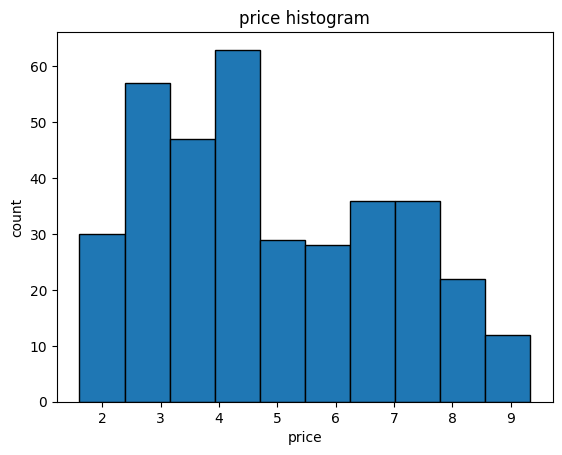

In [144]:
plt.hist(df_clean['price'], bins = 10, edgecolor = 'black')
plt.title('price histogram')
plt.xlabel('price')
plt.ylabel('count')
plt.show()

### 6.2. Столбчатая диаграмма: заказы по дням недели


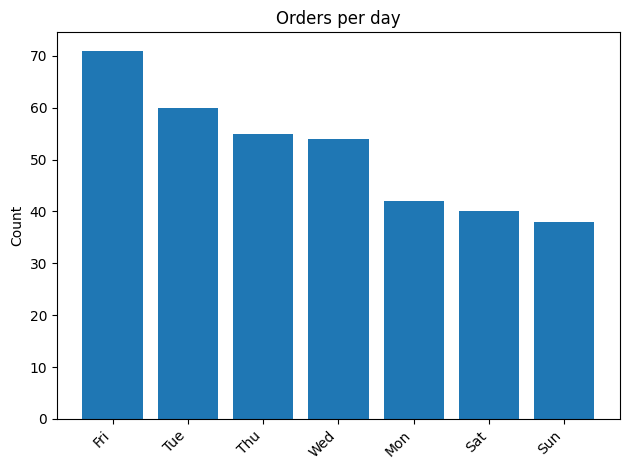

In [145]:

counts = df_clean["day_of_week"].value_counts ()
plt.bar( counts.index.astype(str), counts.values )
plt.xticks(rotation =45 , ha ="right")
plt.ylabel("Count")
plt.title("Orders per day")
plt.tight_layout()
plt.show()



### 6.3. Средняя цена по напитку (barh удобнее читать)


drink
americano        4.093913
cappuccino       5.028833
cold_brew        5.521786
hot_chocolate    4.422222
latte            5.106731
smoothie         6.085098
tea              3.769600
Name: price, dtype: float64


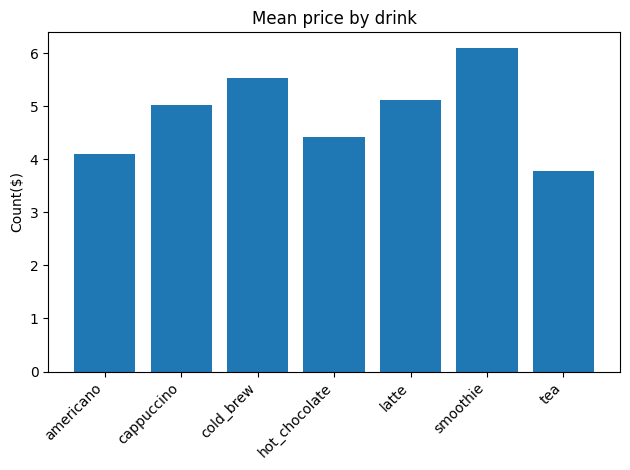

In [146]:
drink_mean = df_clean.groupby('drink')['price'].mean(
)
print(drink_mean)
plt.bar(drink_mean.index.astype(str), drink_mean.values )
plt.xticks(rotation =45 , ha ="right")
plt.ylabel("Count($)")
plt.title("Mean price by drink")
plt.tight_layout()
plt.show()


### 6.4. Scatter: время приготовления vs рейтинг


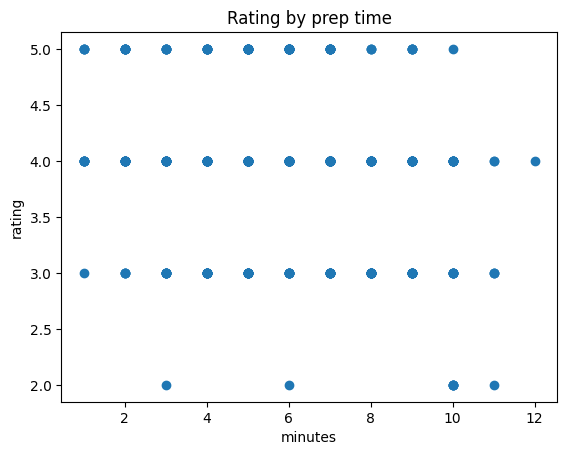

In [147]:
plt.scatter(df_clean['prep_minutes'], df_clean['rating'])
plt.title('Rating by prep time')
plt.xlabel('minutes')
plt.ylabel('rating')
plt.show()


### 6.5. Boxplot калорий по размеру стакана


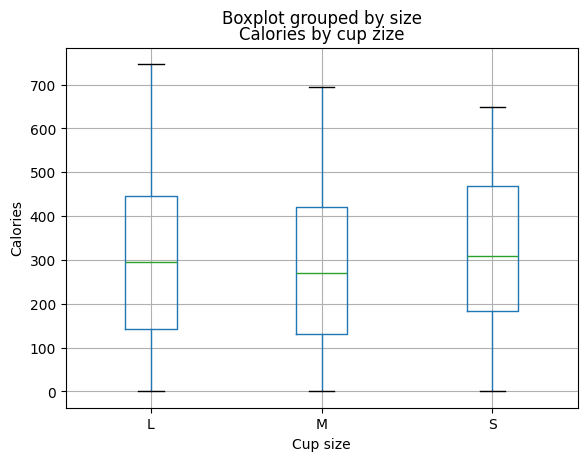

In [148]:
df_clean.boxplot(column='calories', by='size')

plt.title('Calories by cup zize')
plt.xlabel('Cup size')
plt.ylabel('Calories')
plt.show()

### 6.6. Связь учёбы и кофе: study hours vs prior cups (scatter + лёгкий цвет по member)

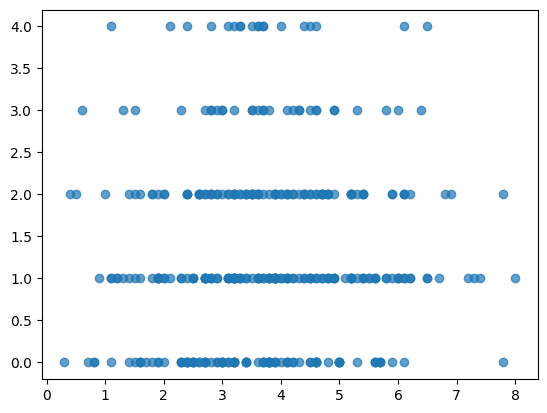

In [149]:
plt.scatter(df_clean['study_hours_today'], df_clean['prior_coffee_cups'], alpha = 0.7)


### Задание A

Посчитайте **средний `tip`** для каждого способа оплаты (`payment`).  
Отсортируйте по убыванию среднего чаевого. Постройте bar chart.


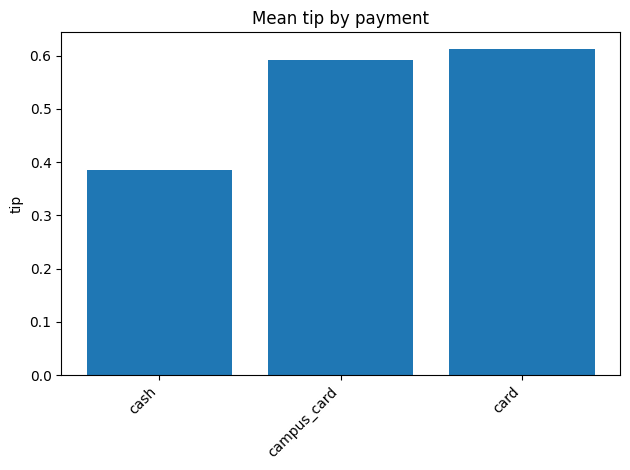

In [150]:
tip_sort = df_clean.groupby('payment')['tip'].mean().sort_values()

plt.bar( tip_sort.index.astype(str), tip_sort.values )
plt.xticks(rotation =45 , ha ="right")
plt.ylabel("tip")
plt.title("Mean tip by payment")
plt.tight_layout()
plt.show()

### Задание B

Сделайте фильтр: только заказы с едой (`food_item != "none"`) **и** `time_slot == "morning"`.  
Сколько таких строк? Какой самый частый `drink` в этом срезе?


In [151]:
food_morn = df_clean[(df_clean['food_item']!='none') & (df_clean['time_slot'] == 'morning')]
print(food_morn)
print("food and morning: ", food_morn.shape[0])
food_morn['drink'].value_counts()


    order_id day_of_week time_slot  student_year   faculty          drink  \
1      B0266         Tue   morning             2       Bio     cappuccino   
22     B0104         Mon   morning             2       Bio     cappuccino   
24     B0331         Mon   morning             4       Law      cold_brew   
26     B0026         Tue   morning             1  Business  hot_chocolate   
38     B0257         Mon   morning             1      Arts          latte   
64     B0016         Thu   morning             1       Bio     cappuccino   
69     B0268         Tue   morning             1        CS       smoothie   
71     B0102         Thu   morning             1        CS            tea   
72     B0346         Sat   morning             3        CS  hot_chocolate   
75     B0062         Wed   morning             1      Arts            tea   
80     B0059         Tue   morning             1    Design      cold_brew   
95     B0044         Tue   morning             4        CS      americano   

,count
drink,
cappuccino,13
latte,11
tea,9
smoothie,7
hot_chocolate,7
americano,6
cold_brew,5
